# tutorial modelo ML+ GA para optimización de proceso


In [3]:
import numpy as np
import pygad
from sklearn.ensemble import RandomForestRegressor

## Paso 1: El escenario (Simulación de tu Modelo Predictivo)

In [4]:
# --- FASE 1: EL PREDICTOR (Simulado) ---
# Imaginamos que tienes datos historicos: [Temperatura, Tiempo] -> [Consumo Energia]
# Generamos datos dummy para entrenar un modelo de juguete
X_train = np.random.rand(100, 2) * [20, 30] + [60, 10]  # Temp (60-80°C), Tiempo (10-40s)
y_train = (X_train[:, 0] * 0.5) + (X_train[:, 1] * 0.2) # Formula inventada de consumo

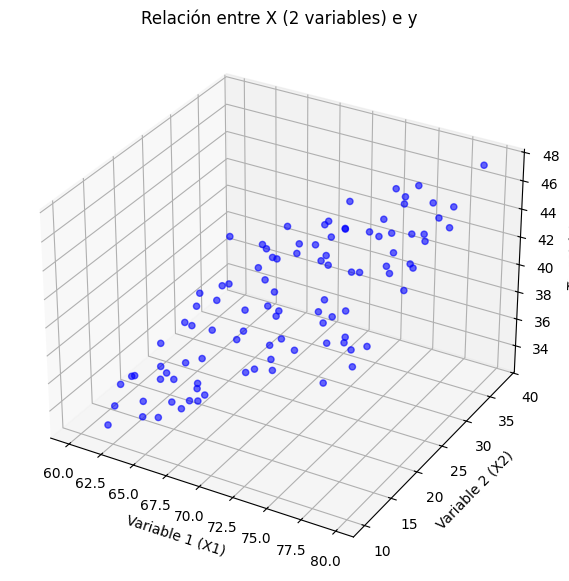

In [9]:
import matplotlib.pyplot as plt

# Crear figura 3D para visualizar cómo y depende de las dos variables de X
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# XTrain[:, 0] es la primera variable (ej. Temp), XTrain[:, 1] es la segunda (ej. Tiempo)
ax.scatter(X_train[:, 0], X_train[:, 1], y_train, c='blue', marker='o', alpha=0.6)

ax.set_xlabel('Variable 1 (X1)')
ax.set_ylabel('Variable 2 (X2)')
ax.set_zlabel('Target (y)')
ax.set_title('Relación entre X (2 variables) e y')

plt.show()

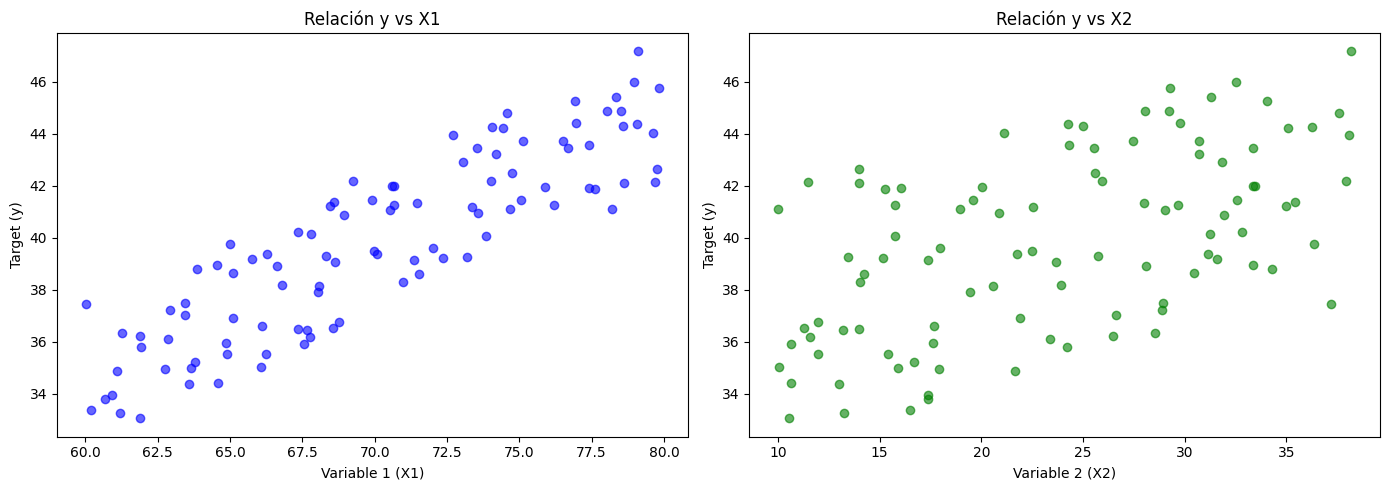

In [10]:
# Visualizar y en función de cada componente de X por separado

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de y vs X1 (Temp)
axes[0].scatter(X_train[:, 0], y_train, c='blue', alpha=0.6)
axes[0].set_xlabel('Variable 1 (X1)')
axes[0].set_ylabel('Target (y)')
axes[0].set_title('Relación y vs X1')

# Gráfico de y vs X2 (Tiempo)
axes[1].scatter(X_train[:, 1], y_train, c='green', alpha=0.6)
axes[1].set_xlabel('Variable 2 (X2)')
axes[1].set_ylabel('Target (y)')
axes[1].set_title('Relación y vs X2')

plt.tight_layout()
plt.show()

In [11]:
# Entrenamos el "Digital Twin" del pasteurizador
modelo_predictor = RandomForestRegressor()
modelo_predictor.fit(X_train, y_train)

print("Modelo predictor entrenado. Ahora actuará como 'simulador' de la planta.")

Modelo predictor entrenado. Ahora actuará como 'simulador' de la planta.


In [14]:
y = modelo_predictor.predict(X_train)
MAE = np.mean(np.abs(y - y_train))
print(f"Error medio absoluto del modelo predictor: {MAE}")

Error medio absoluto del modelo predictor: 0.1427930872253618


## Paso 2: El Optimizador (Algoritmo Genético)

In [ ]:
# --- FASE 2: EL OPTIMIZADOR (Algoritmo Genético) ---

def fitness_func(ga_instance, solution, solution_idx):
    """
    Función de evaluación (Fitness Function) para el Algoritmo Genético.
    
    El objetivo es MINIMIZAR el consumo energético.
    Dado que PyGAD siempre busca MAXIMIZAR el fitness, retornamos el valor negativo del consumo.
    
    Args:
        ga_instance: Instancia del algoritmo genético.
        solution (list): Lista de genes (parámetros) de la solución actual [Temperatura, Tiempo].
        solution_idx (int): Índice de la solución en la población.
        
    Returns:
        float: Valor de fitness (negativo del consumo predicho). 
               Si viola restricciones, retorna un valor muy bajo (penalización).
    """
    
    # 1. Decodificar los genes (variables de decisión)
    temperatura = solution[0]
    tiempo = solution[1]
    
    # ---------------------------------------------------------
    # 2. DEFINICIÓN DE RESTRICCIONES (Hard Constraints)
    # ---------------------------------------------------------
    # Restricción de seguridad: La temperatura debe ser al menos 72.3°C para pasteurización.
    # Margen de seguridad termodinámico + tolerancia de instrumentación:
    # Límite legal: 72.0°C. Setpoint: 72.3°C (+0.3°C para absorber incertidumbre
    # del sensor PT100 Clase A ±0.3°C segun IEC 60751 y tolerancia PMO-FDA ±0.5°F)
    MIN_TEMP_SEGURIDAD = 72.3
    PENALIZACION_SEVERA = -99999999  # Un número muy negativo para descartar la solución
    
    if temperatura < MIN_TEMP_SEGURIDAD:
        return PENALIZACION_SEVERA 
    
    # ---------------------------------------------------------
    # 3. EVALUACIÓN CON MODELO PREDICTIVO (Digital Twin)
    # ---------------------------------------------------------
    # Consultamos al modelo ML: "¿Cuánta energía gasta esta configuración?"
    # Formateamos la entrada para el modelo sklearn: [[Temp, Tiempo]]
    inputs = np.array([solution]) 
    
    # Predecimos el consumo energético estimado
    consumo_predicho = modelo_predictor.predict(inputs)[0]
    
    # ---------------------------------------------------------
    # 4. RETORNO DEL FITNESS
    # ---------------------------------------------------------
    # Retornamos el valor negativo para convertir el problema de minimización 
    # en uno de maximización (como requiere PyGAD).
    return -consumo_predicho

In [19]:
# Configuración del Algoritmo
ga_instance = pygad.GA(
    num_generations=500, # Número de generaciones
    num_parents_mating=50, # Número de padres que se aparean
    fitness_func=fitness_func,
    sol_per_pop=100, # tamaño de la población
    num_genes=2,
    gene_type=float,
    
    # Rangos de búsqueda (Espacio de diseño)
    # Gen 0 (Temp): Min 70°C, Max 90°C
    # Gen 1 (Tiempo): Min 10s, Max 60s
    gene_space=[{'low': 70, 'high': 90}, {'low': 10, 'high': 60}],
    
    parent_selection_type="sss", # Steady-state selection
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=10
)

c:\Users\vgarc\Documents\Proyectos\DATAGIA-local\.venv\lib\site-packages\pygad\pygad.py:753: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(f"The percentage of genes to mutate (mutation_percent_genes={mutation_percent_genes}) resulted in selecting ({mutation_num_genes}) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).\nIf you do not want to mutate any gene, please set mutation_type=None.")


In [20]:
# Ejecutar optimización
print("Iniciando evolución...")
ga_instance.run()

# --- RESULTADOS ---
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print(f"\n--- MEJOR CONFIGURACIÓN ENCONTRADA ---")
print(f"Temperatura Óptima: {solution[0]:.2f} °C")
print(f"Tiempo Óptimo: {solution[1]:.2f} s")
print(f"Consumo Energético Predicho (Minimizado): {-solution_fitness:.2f} kWh")

Iniciando evolución...

--- MEJOR CONFIGURACIÓN ENCONTRADA ---
Temperatura Óptima: 72.01 °C
Tiempo Óptimo: 10.09 s
Consumo Energético Predicho (Minimizado): 38.23 kWh
